In [42]:
import numpy as np

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd   
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler    
  


In [44]:
url = "https://raw.githubusercontent.com/selva86/datasets/master/GermanCredit.csv"
df = pd.read_csv(url)

df.head()

,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk
0,... < 100 DM,6,critical account/other credits existing,domestic appliances,1169,unknown/no savings account,... >= 7 years,4,male : single,none,...,real estate,67,none,own,2,skilled employee/official,1,yes,yes,1
1,0 <= ... < 200 DM,48,existing credits paid back duly till now,domestic appliances,5951,... < 100 DM,1 <= ... < 4 years,2,female : divorced/separated/married,none,...,real estate,22,none,own,1,skilled employee/official,1,no,yes,0
2,no checking account,12,critical account/other credits existing,retraining,2096,... < 100 DM,4 <= ... < 7 years,2,male : single,none,...,real estate,49,none,own,1,unskilled - resident,2,no,yes,1
3,... < 100 DM,42,existing credits paid back duly till now,radio/television,7882,... < 100 DM,4 <= ... < 7 years,2,male : single,guarantor,...,building society savings agreement/life insurance,45,none,for free,1,skilled employee/official,2,no,yes,1
4,... < 100 DM,24,delay in paying off in the past,car (new),4870,... < 100 DM,1 <= ... < 4 years,3,male : single,none,...,unknown/no property,53,none,for free,2,skilled employee/official,2,no,yes,0


In [45]:
# import os
# os.makedirs("../data/raw", exist_ok=True)
# df.to_csv("../data/raw/credit_data.csv", index=False)

In [46]:
df.shape

(1000, 21)

In [47]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   status                   1000 non-null   str  
 1   duration                 1000 non-null   int64
 2   credit_history           1000 non-null   str  
 3   purpose                  1000 non-null   str  
 4   amount                   1000 non-null   int64
 5   savings                  1000 non-null   str  
 6   employment_duration      1000 non-null   str  
 7   installment_rate         1000 non-null   int64
 8   personal_status_sex      1000 non-null   str  
 9   other_debtors            1000 non-null   str  
 10  present_residence        1000 non-null   int64
 11  property                 1000 non-null   str  
 12  age                      1000 non-null   int64
 13  other_installment_plans  1000 non-null   str  
 14  housing                  1000 non-null   str  
 15  number_credits  

In [48]:
df.isnull().sum()

status                     0
duration                   0
credit_history             0
purpose                    0
amount                     0
savings                    0
employment_duration        0
installment_rate           0
personal_status_sex        0
other_debtors              0
present_residence          0
property                   0
age                        0
other_installment_plans    0
housing                    0
number_credits             0
job                        0
people_liable              0
telephone                  0
foreign_worker             0
credit_risk                0
dtype: int64

In [49]:
df['credit_history'].value_counts() 

credit_history
existing credits paid back duly till now       530
critical account/other credits existing        293
delay in paying off in the past                 88
all credits at this bank paid back duly         49
no credits taken/all credits paid back duly     40
Name: count, dtype: int64

In [50]:

df['credit_history'] = df['credit_history'].str.strip().str.lower()

# Step 2: Mapping (also lowercase)
df['credit_category'] = df['credit_history'].map({
    "existing credits paid back duly till now": "Excellent",
    "all credits at this bank paid back duly": "Excellent",
    
    "no credits taken/all credits paid back duly": "Good",
    
    "critical account/other credits existing": "Average",
    "delay in paying off in the past": "Average"
}).fillna("Poor")

Text(0.5, 1.0, 'Credit History Distribution')

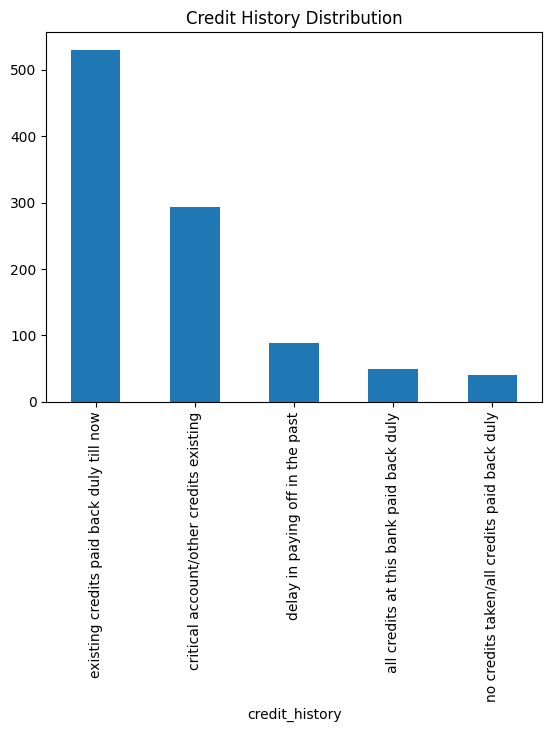

In [51]:
df['credit_history'].value_counts().plot(kind='bar')
plt.title('Credit History Distribution')

In [52]:
df['credit_category'].value_counts()

credit_category
Excellent    579
Average      381
Good          40
Name: count, dtype: int64

Text(0.5, 1.0, 'Credit History Distribution')

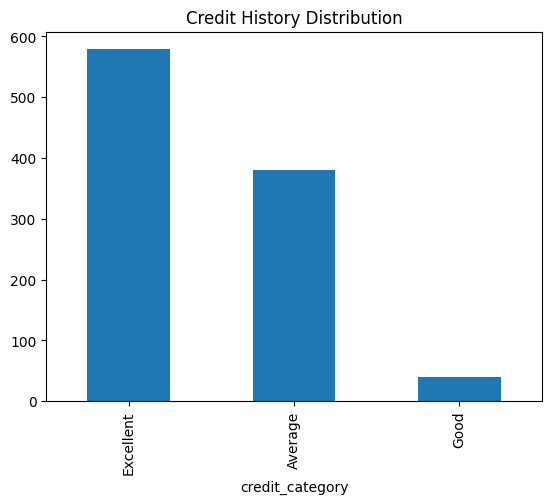

In [53]:
df['credit_category'].value_counts().plot(kind='bar')
plt.title('Credit History Distribution')